In [1]:
import jax
import jax.numpy as jnp
from src.simulators.gauss_rw import mixture_rw_trajectory

from src.models.score_net import ScoreNet

import matplotlib.pyplot as plt

In [2]:
key = jax.random.PRNGKey(22)
dim = 2
T = 10

theta = jnp.array([2.0, -1.0])
x_0 = jnp.zeros(dim)

trajectory = mixture_rw_trajectory(theta, x_0, T, key )
print(f"Trajectory shape: {trajectory.shape}")

Trajectory shape: (11, 2)


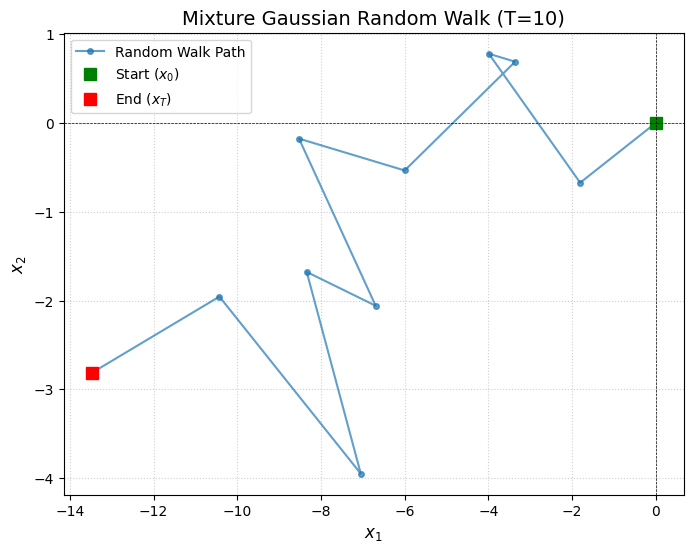

In [11]:
# visualize the trajectory
plt.figure(figsize=(8, 6))

plt.plot(trajectory[:, 0], trajectory[:, 1], 'o-', markersize=4, alpha=0.7, label='Random Walk Path')

plt.plot(trajectory[0, 0], trajectory[0, 1], 'gs', markersize=8, label='Start ($x_0$)')
plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'rs', markersize=8, label='End ($x_T$)')


plt.title(f'Mixture Gaussian Random Walk (T={len(trajectory)-1})', fontsize=14)
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.axhline(0, color='black', lw=0.5, ls='--') 
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

In [ ]:
model = ScoreNet(hidden_dim=128, out_dim=2)

key = jax.random.PRNGKey(0)
dummy_theta = jnp.ones((1, 2))
dummy_x = jnp.ones((1, 2))
dummy_a = jnp.ones((1, 1))

params = model.init(key, dummy_theta, dummy_x, dummy_x, dummy_a)['params']